# Création de datasets

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from utils import generate_gratings, StaticGratingsDataset, NaturalScenesDataset

In [2]:
def plot_data_samples(stimulus: np.ndarray, activation: np.ndarray, n_samples: int, random_sate: int = None):
    """
    Plots samples from a dataset (stimulus and neural activations). 

    Inputs
        stimulus: stimulus data
        activation: neural activations data
        n_samples: number of samples to show
        random_sate: random seed
    """
    if random_sate!=None:
        np.random.seed(random_sate)
    samples = np.random.choice(range(stimulus.shape[0]),size=n_samples,replace=False)
    if n_samples>1:
        fig, ax = plt.subplots(nrows=n_samples,ncols=2,figsize=(10,10))
        for i, x in enumerate(samples):
            if stimulus.ndim==3:
                ax[i,0].imshow(stimulus[i],cmap="gray")
            else:
                stim = generate_gratings([stimulus[i,0]],[stimulus[i,1]],[stimulus[i,2]])
                ax[i,0].imshow(stim[0],cmap="gray")
                ax[i,0].text(1.05, 0.8, f"orientation={stimulus[i,0]}", transform=ax[i,0].transAxes, fontsize=8, va='top')
                ax[i,0].text(1.05, 0.6, f"spatial_frequency={stimulus[i,1]}", transform=ax[i,0].transAxes, fontsize=8, va='top')
                ax[i,0].text(1.05, 0.4, f"phase={stimulus[i,2]}", transform=ax[i,0].transAxes, fontsize=8, va='top')
            ax[i,0].axis("off")
            ax[i,1].imshow(activation[i].T,aspect="auto")
            ax[i,1].set_xlabel("Timestep")
            ax[i,1].set_ylabel("Unit")
    else:
        fig, ax = plt.subplots(ncols=2,figsize=(8,6))
        if stimulus.ndim==3:
            ax[0].imshow(stimulus[samples[0]],cmap="gray")
        else:
            stim = generate_gratings([stimulus[samples[0],0]],[stimulus[samples[0],1]],[stimulus[samples[0],2]])
            ax[0].imshow(stim[0],cmap="gray")
            ax[0].text(1.05, 0.8, f"orientation={stimulus[samples[0],0]}", transform=ax[0].transAxes, fontsize=10, va='top')
            ax[0].text(1.05, 0.6, f"spatial_frequency={stimulus[samples[0],1]}", transform=ax[0].transAxes, fontsize=10, va='top')
            ax[0].text(1.05, 0.4, f"phase={stimulus[samples[0],2]}", transform=ax[0].transAxes, fontsize=10, va='top')
        ax[0].axis("off")
        ax[1].imshow(activation[samples[0]].T,aspect="auto")
        ax[1].set_xlabel("Timestep")
        ax[1].set_ylabel("Unit")
    plt.tight_layout()
    plt.show()

## Static gratings

In [3]:
sg_dataset = StaticGratingsDataset(750332458)
sg_dataset

StaticGratingsDataset(session_id=750332458)

In [4]:
h_v_bars = sg_dataset.get_presentation_ids(orientation=[0,90])
len(h_v_bars)

1931

In [5]:
visp_units = sg_dataset.get_unit_ids("VISp")
len(visp_units)

63

In [6]:
X_sg, y_sg = sg_dataset.get_data(presentation_ids=h_v_bars,unit_ids=visp_units,stimulus_type="params")
X_sg.shape, y_sg.shape

((1931, 3), (1931, 100, 63))

Ici on n'a choisi que des gratings avec barres horizontales et verticales et des units de la région VISp.  
Mais on aurait pu tout sélectionner ou choisir autre chose. 

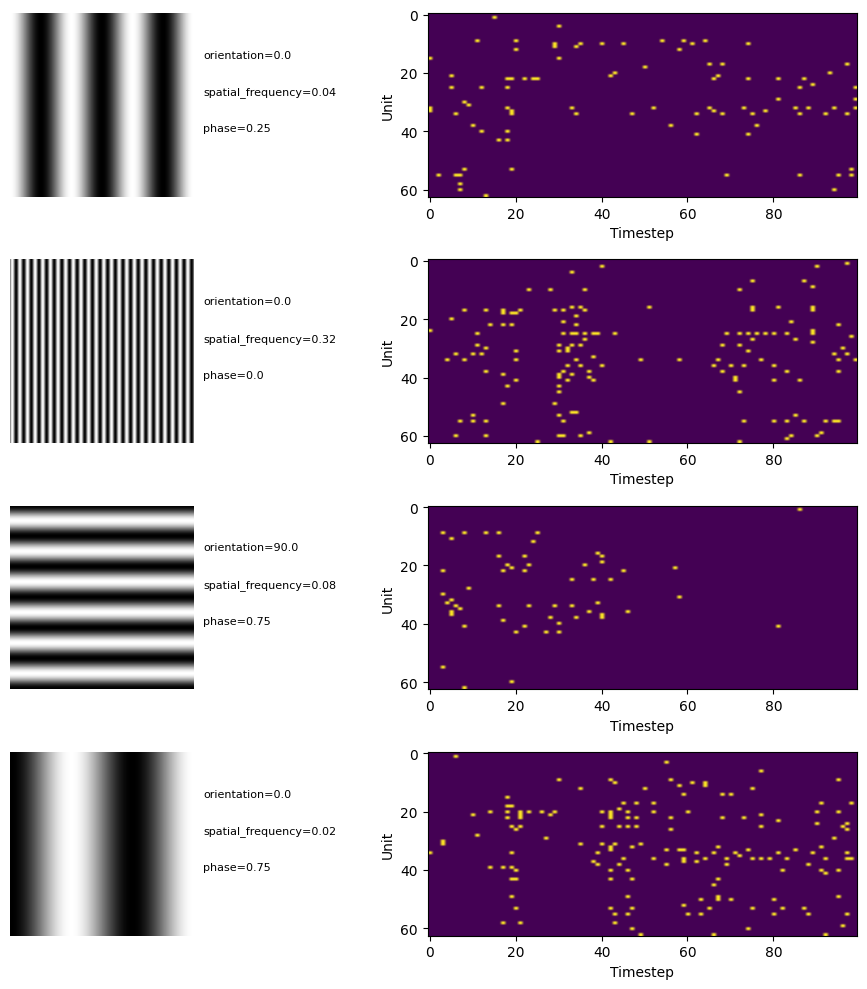

In [7]:
plot_data_samples(X_sg,y_sg,4)

## Natural scenes

In [8]:
ns_dataset = NaturalScenesDataset(750332458)
ns_dataset

NaturalScenesDataset(session_id=750332458)

In [9]:
X_ns, y_ns = ns_dataset.get_data()
X_ns.shape, y_ns.shape

((5950, 918, 1174), (5950, 100, 295))

Ici, on a choisit de garder toutes les images et tous les units. 

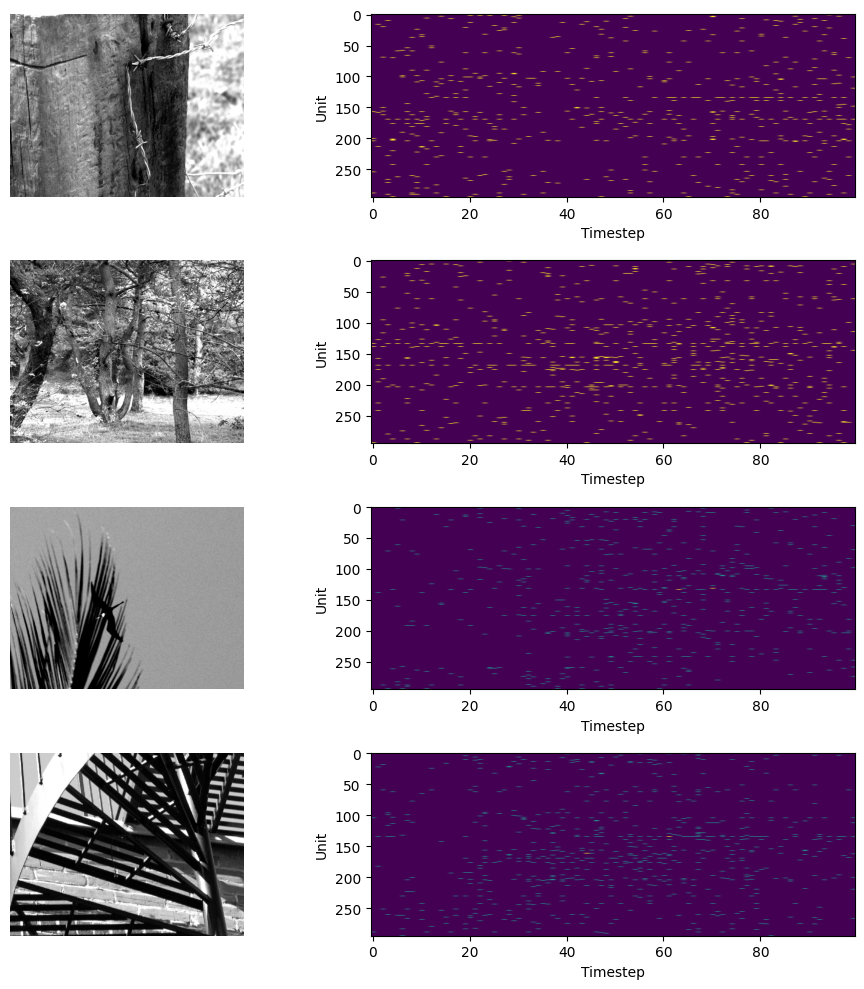

In [10]:
plot_data_samples(X_ns,y_ns,4)